NYC Taxi Trip Analysis – Data Cleaning & Insight Generation


Problem Statement :

---

The objective of this project is to analyze real-world NYC taxi trip data to understand trip behavior, pricing patterns, and demand trends.
The dataset contains raw and uncleaned operational data, which may include missing values, incorrect entries, and inconsistencies.
The main problem is to clean and process this data effectively and extract meaningful insights such as peak demand hours, fare patterns, customer tipping behavior, and operational inefficiencies.
These insights can help improve pricing strategies, optimize operations, and enhance customer experience in a ride-hailing business.





In [1]:
# Importing required libraries for the project
import pandas as pd
import numpy as np

In [2]:
# Loading the dataset
df = pd.read_csv("/content/yellow_tripdata_2020-06 - yellow_tripdata_2020-06.csv.csv")

/tmp/ipykernel_1268/2926177420.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/yellow_tripdata_2020-06 - yellow_tripdata_2020-06.csv.csv")


In [3]:
# Taking 45,000 rows randomly as per instructions
df = df.sample(n=45000, random_state=42)

In [4]:
# Display first 5 rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
126223,2.0,2020-06-10 13:36:49,2020-06-10 13:51:08,1.0,2.73,1.0,N,224,148,2.0,12.00,0.0,0.5,0.00,0.00,0.3,15.30,2.5
519501,NaN,2020-06-13 6:19:00,2020-06-13 6:37:00,NaN,11.58,NaN,NaN,56,42,NaN,28.81,0.0,0.5,0.00,6.12,0.3,35.73,0.0
284266,2.0,2020-06-20 7:59:23,2020-06-20 8:05:39,1.0,2.05,1.0,N,79,68,2.0,8.00,0.0,0.5,0.00,0.00,0.3,11.30,2.5
431328,1.0,2020-06-27 15:11:32,2020-06-27 15:15:02,1.0,1.40,1.0,N,236,75,1.0,6.00,2.5,0.5,1.85,0.00,0.3,11.15,2.5
414269,1.0,2020-06-26 16:00:36,2020-06-26 16:02:28,1.0,0.60,1.0,N,186,90,2.0,4.00,3.5,0.5,0.00,0.00,0.3,8.30,2.5


SECTION 1: Data Cleaning & Preparation (Step-by-Step)

Step 1: Initial Exploration

In [5]:
# Checking Shape of the dataset
df.shape

# Here 45000 belongs to no.of rows in dataset and 18 belongs to no.of columns in dataset

(45000, 18)

In [6]:
# Checking Column names in the dataset
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

In [7]:
# Checking Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45000 entries, 126223 to 285051
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               40777 non-null  float64
 1   tpep_pickup_datetime   45000 non-null  object 
 2   tpep_dropoff_datetime  45000 non-null  object 
 3   passenger_count        40777 non-null  float64
 4   trip_distance          45000 non-null  float64
 5   RatecodeID             40777 non-null  float64
 6   store_and_fwd_flag     40777 non-null  object 
 7   PULocationID           45000 non-null  int64  
 8   DOLocationID           45000 non-null  int64  
 9   payment_type           40777 non-null  float64
 10  fare_amount            45000 non-null  float64
 11  extra                  45000 non-null  float64
 12  mta_tax                45000 non-null  float64
 13  tip_amount             45000 non-null  float64
 14  tolls_amount           45000 non-null  float64
 15  i

In [8]:
# Separating column types into Numerical columns ,Categorical columns and Datetime columns


# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Datetime columns
datetime_cols = df.select_dtypes(["datetime64[ns]"]).columns

# Displaying the columns
print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)
print("\nDatetime Columns:\n", datetime_cols)

Numerical Columns:
 Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

Categorical Columns:
 Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag'], dtype='object')

Datetime Columns:
 Index([], dtype='object')


Step 2: NumPy-Based Analysis

In [9]:
# Finding mean ,median and std.deviation of trip_distance ,fare_amount and total_amount using numpy

# Define columns
cols = ["trip_distance", "fare_amount", "total_amount"]

# Create DataFrame
summary_stats = pd.DataFrame(index=cols, columns=["Mean", "Median", "Std"])

# Calculate values
summary_stats["Mean"] = np.mean(df[cols], axis=0)
summary_stats["Median"] = np.median(df[cols], axis=0)
summary_stats["Std"] = np.std(df[cols], axis=0)

# Display
summary_stats

# Here I have created a summary statistics table to compare mean, median, and standard deviation across key numerical features, which made it easier to identify variations and potential outliers.

# Observation:

# 1. Trip Distance:
# The mean (3.37) is higher than the median (1.87), indicating right-skewed distribution with presence of long-distance outliers.

# 2. Fare Amount:
# The mean (13.64) is higher than the median (9.00), showing that a few trips have very high fares (outliers).

# 3. Total Amount:
# The mean (18.83) is greater than the median (14.16), indicating variability in total cost due to additional charges like tips, tolls, etc.

# 4. Standard Deviation:
# High standard deviation in all three columns suggests large variation in trip distances and pricing, confirming the presence of inconsistent values and strong indication of outliers.

,Mean,Median,Std
trip_distance,3.372960,1.87,4.298908
fare_amount,13.647337,9.00,13.443683
total_amount,18.839376,14.16,15.067955


Step 3: Data Type Corrections

In [10]:
# Convert to datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [11]:
# Checking whether the datatype of the colums is changed or not
df.dtypes

,0
VendorID,float64
tpep_pickup_datetime,datetime64[ns]
tpep_dropoff_datetime,datetime64[ns]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,float64


In [12]:
print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)
print("\nDatetime Columns:\n", datetime_cols)

# Observation:
# The pickup and dropoff columns were initially in object format and now they were successfully converted into datetime format.

Numerical Columns:
 Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

Categorical Columns:
 Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag'], dtype='object')

Datetime Columns:
 Index([], dtype='object')


Step 4: Missing Value Handling

In [13]:
# Checking for missing values
df.isnull().sum()

# Here we can observe no.of missing values in some columns such as vendorid,passenger_count,RatecodeID,store_and_fwd_flag,payment_type...

,0
VendorID,4223
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,4223
trip_distance,0
RatecodeID,4223
store_and_fwd_flag,4223
PULocationID,0
DOLocationID,0
payment_type,4223


In [14]:
# Now Handling missing values using appropriate techniques such as fill(),drop()..

# VendorID

df['VendorID'] = df['VendorID'].fillna(df['VendorID'].mode()[0])

# Here to fill missing values in vendorID i have used mode rather than mean or median bcz it is a category... so it can have repeated values so using mean or median makes no sense..

In [15]:
# passenger_count

df['passenger_count'] = df['passenger_count'].fillna(df['passenger_count'].median())

# Here to fill missing values in passenger_count i have used median bcz it is numerical data and it can have outliers also... So inorder to overcome errors using median is safe and realistic.

In [16]:
# RatecodeID

df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])

# Same here RatecideID is a category... So i have used mode.

In [17]:
# store_and_fwd_flag

df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0])

# Same here store_and_fwd_flag is a category... So i have used mode.

In [18]:
# payment_type

df['payment_type'] = df['payment_type'].fillna(df['payment_type'].mode()[0])

# Same here payment_type is a categorical(Cash/Card)... So i have used mode.

In [19]:
# tip_amount

df['tip_amount'] = df['tip_amount'].fillna(0)

# Here in this column if tip is missing means that there is no tip has given... So i have filled it with zero(0).

# Different techniques were used based on the nature of the data.Median was used for numerical columns to handle outliers, mode was used for categorical columns, and logical assumptions were applied where appropriate.

In [20]:
# Checking for missing values again after handling missing values..
df.isnull().sum()

# Here we can observe that no missing values are present..

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


Step 5 : Remove Invalid Records

In [21]:
# Checking and Removing logically incorrect / impossible data like
#passenger_count = 0
#trip_distance ≤ 0
#fare_amount ≤ 0
#total_amount ≤ 0

# These are invalid in real-world taxi data If we don’t remove these analysis becomes wrong and Affects:
# averages
# graphs
# insights

In [22]:
# Check passenger_count = 0
df[df['passenger_count'] < 1].shape

# Here i have taken <1 bcz some values can be less than zero(0).and we can see 1048 invalid records are present..

(1048, 18)

In [23]:
# Removing invalid records

df = df[df['passenger_count'] > 0]
df.shape

# Total 45000 - 1048

(43952, 18)

In [24]:
# Check trip_distance ≤ 0
df[df['trip_distance'] <= 0].shape

# Here we can see 1352 invalid records are present

(1352, 18)

In [25]:
df = df[df['trip_distance'] > 0]
df.shape

#43952 - 1352

(42600, 18)

In [26]:
# Check fare_amount ≤ 0
df[df['fare_amount'] <= 0].shape

# Here we can see 209 invalid records are present

(209, 18)

In [27]:
df = df[df['fare_amount'] > 0]
df.shape

# 42600 - 209

(42391, 18)

In [28]:
# Check total_amount ≤ 0
df[df['total_amount'] <= 0].shape

# As we can see here no invalid records are present in total amount column

(0, 18)

In [29]:
df = df[df['total_amount'] > 0]
df.shape

# As ther were no invalid records But still i have written this to make sure the code should run perfectly on another datasets also..

# Observation:
# Invalid records were identified and removed step-by-step to ensure dat quality.
# Trips with zero passengers, zero or negative distance,
# and invalid fare and total amounts were eliminated.
# This ensures the dataset contains only valid and realistic records.

(42391, 18)

Step 6: Duplicate Handling

In [30]:
# Checking for duplicate rows and removing them if present

df.duplicated().sum()

# As we can see no duplicate rows are present in this dataset..
# 0 = no duplicates , >0 = duplicates exist..

np.int64(0)

In [31]:
# To View duplicate rows if present
df[df.duplicated()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge


In [32]:
# Remove duplicates
df = df.drop_duplicates()

# As there are no duplicates nothing is dropped..

In [33]:
# Verify removal
df.duplicated().sum()

# Observation:
# Duplicate records were checked and removed from the dataset.
# This ensures that each trip is counted only once,
# improving the accuracy of analysis.

np.int64(0)

Step 7: Categorical Cleaning

In [34]:
# Clean and standardize categorical columns
# Remove inconsistencies
# Ensure uniform values

# Here in this dataset we have categorical columns such as payment_type and store_and_fwd_flag

In [35]:
# Checking for unique values

print("Payment Type Values:\n", df['payment_type'].unique())
print("\nStore and Fwd Flag Values:\n", df['store_and_fwd_flag'].unique())

# As we can observe here The payment_type column contained numeric values of float type that needs to convert into int type and The store_and_fwd_flag column was consistent..

Payment Type Values:
 [2. 1. 3. 4. 5.]

Store and Fwd Flag Values:
 ['N' 'Y']


In [36]:
#changing datatype of payment_type to int to ignore inconsistent values..
df['payment_type']=df['payment_type'].astype("int")
df['payment_type'].unique()

array([2, 1, 3, 4, 5])

In [37]:
# Clean store_and_fwd_flag (standardize case)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].str.upper()

# The store_and_fwd_flag column was standardized to ensure uniform representation.
# This step has done to control the inconsistent values while used on another dataset..As The data was already in a consistent format, so only minor standardization was applied.

In [38]:
# Checking again

print("Payment Type Values:\n", df['payment_type'].unique())
print("\nStore and Fwd Flag Values:\n", df['store_and_fwd_flag'].unique())



Payment Type Values:
 [2 1 3 4 5]

Store and Fwd Flag Values:
 ['N' 'Y']


Step 8: Datetime Feature Engineering

In [39]:
# Extract pickup_hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [40]:
# Extract pickup_day (date)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day

In [41]:
# Extract day_of_week
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

In [42]:
# Extract month
df['month'] = df['tpep_pickup_datetime'].dt.month

In [43]:
# Verify new columns
df[['tpep_pickup_datetime', 'pickup_hour', 'pickup_day', 'day_of_week', 'month']].head()

# I extracted time-based features such as hour, day, weekday, and month from the pickup datetime column. These features help in analyzing demand patterns and peak hours.

,tpep_pickup_datetime,pickup_hour,pickup_day,day_of_week,month
126223,2020-06-10 13:36:49,13,10,Wednesday,6
519501,2020-06-13 06:19:00,6,13,Saturday,6
284266,2020-06-20 07:59:23,7,20,Saturday,6
431328,2020-06-27 15:11:32,15,27,Saturday,6
414269,2020-06-26 16:00:36,16,26,Friday,6


Step 9: Trip Duration

In [44]:
# Here we have to Create a new column: trip_duration
# Remove :
# Negative durations
# Unrealistic durations

# Trip duration helps in:

# Traffic analysis
# Efficiency analysis
# Identifying abnormal trips

In [45]:
# Create trip_duration
# We calculate:
# dropoff time - pickup time

df['trip_duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['trip_duration'].head(5)

,trip_duration
126223,0 days 00:14:19
519501,0 days 00:18:00
284266,0 days 00:06:16
431328,0 days 00:03:30
414269,0 days 00:01:52


In [46]:
# Converting duration to minutes

df['trip_duration'] = df['trip_duration'].dt.total_seconds() / 60
df['trip_duration'].head(5)

,trip_duration
126223,14.316667
519501,18.000000
284266,6.266667
431328,3.500000
414269,1.866667


In [47]:
# Check negative durations

df[df['trip_duration'] < 0].shape

# We can observe that there are no negative durations in our dataset..

(0, 23)

In [48]:
# Remove negative durations

df = df[df['trip_duration'] > 0]
df.shape

# I have written this to remove negative durations from the dataset... As there were no negative durations in this dataset still i have written this to work this code efficiently on another datasets..

(42384, 23)

In [49]:
# Here unrealistic durations means Duration ≤ 0 and Duration > 300 minutes (5 hours)
# Duration ≤ 0 are already removed

# Count unrealistic values

df[df['trip_duration'] > 300].shape

# As we can observe that here we have 78 unrealistic durations..

(78, 23)

In [50]:
# Remove unrealistic durations

df = df[df['trip_duration'] < 300]
df.shape

# 42384 - 78

# Trips with duration greater than 300 minutes were identified as unrealistic.
# These records were removed to ensure data accuracy.
# The dataset size reduced after removing these extreme values.

(42306, 23)

Step 10: Outlier Detection

In [51]:
# Outlier Detection using boxplots
# Outliers can:

# Distort averages
# Mislead insights
# Indicate errors or rare events

In [52]:
# Import libraries

import matplotlib.pyplot as plt
import seaborn as sns

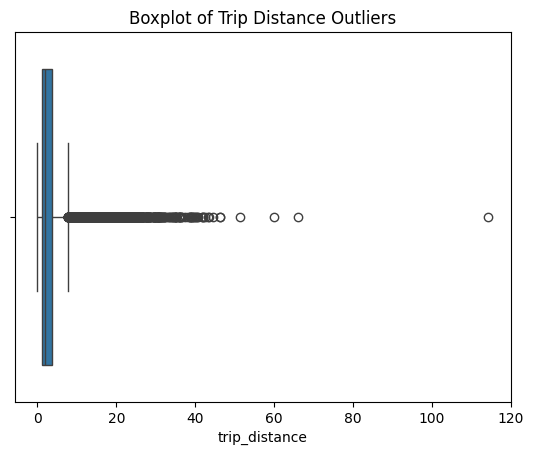

In [53]:
# Boxplot for trip_distance

plt.figure()
sns.boxplot(x=df['trip_distance'])
plt.title("Boxplot of Trip Distance Outliers")
plt.show()

# We can observe that many outliers are present..

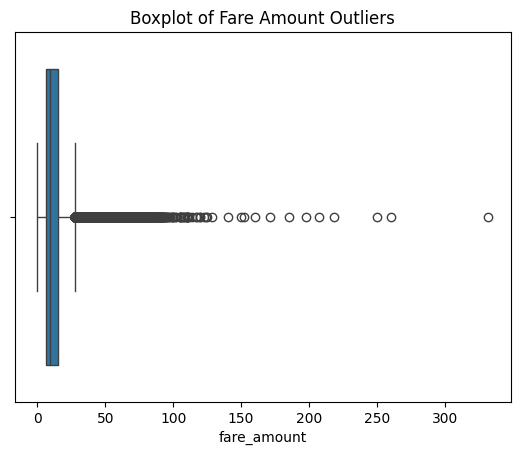

In [54]:
# Boxplot for fare_amount

plt.figure()
sns.boxplot(x=df['fare_amount'])
plt.title("Boxplot of Fare Amount Outliers")
plt.show()

# We can observe that many outliers are present..

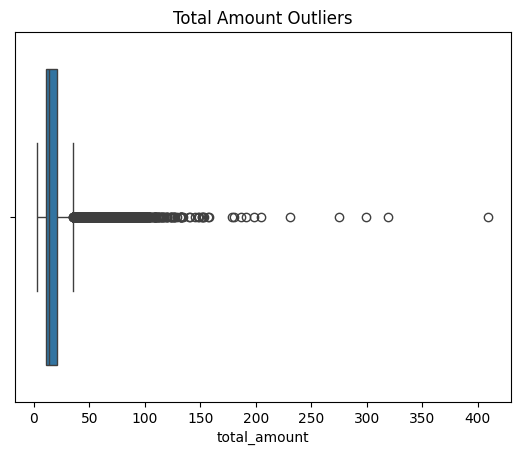

In [55]:
# Boxplot for total_amount

plt.figure()
sns.boxplot(x=df['total_amount'])
plt.title("Total Amount Outliers")
plt.show()

# We can observe that many outliers are present..

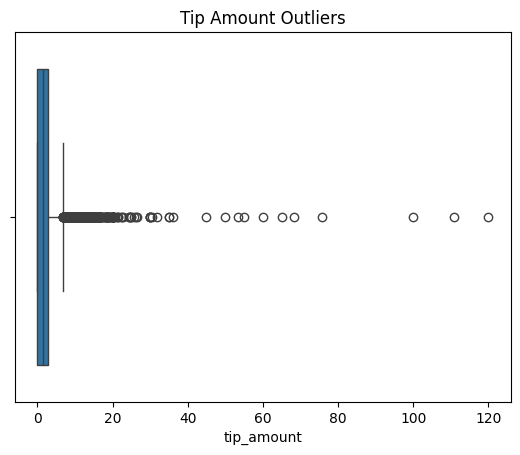

In [56]:
# Boxplot for tip_amount

plt.figure()
sns.boxplot(x=df['tip_amount'])
plt.title("Tip Amount Outliers")
plt.show()

# We can observe that many outliers are present..

# Boxplots revealed the presence of outliers in all key numerical columns.
# Trip distance and fare amount show right-skewed distributions with extreme values.
# These outliers may represent long-distance trips or abnormal pricing.

Step 11: Feature Engineering

In [57]:
# Creating new useful features:

# fare_per_km
# tip_percentage
# trip_speed
# These help in better insights and analysis...

In [58]:
# Create fare_per_km

df['fare_per_km'] = df['fare_amount'] / df['trip_distance']

# It Shows cost efficiency..

In [59]:
# Create tip_percentage

df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100

# Shows customer tipping behavior..

In [60]:
# Create trip_speed

df['trip_speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

# Converting minutes to hours..

In [61]:
# Verify new columns

df[['fare_per_km', 'tip_percentage', 'trip_speed']].head()

# New features such as fare per km, tip percentage, and trip speed were created.
# These features help in understanding pricing efficiency, customer tipping behavior, travel speed, enabling deeper analysis.

,fare_per_km,tip_percentage,trip_speed
126223,4.395604,0.000000,11.441211
519501,2.487910,0.000000,38.600000
284266,3.902439,0.000000,19.627660
431328,4.285714,30.833333,24.000000
414269,6.666667,0.000000,19.285714


Step 12: Final Validation

In [62]:
# Ensure:
# Clean dataset
# No invalid values
# Ready for analysis

In [63]:
# Check missing values
df.isnull().sum()

# There are no missing values..

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [64]:
# Checking invalid values

print((df['passenger_count'] <= 0).sum())
print((df['trip_distance'] <= 0).sum())
print((df['fare_amount'] <= 0).sum())
print((df['total_amount'] <= 0).sum())
print((df['trip_duration'] <= 0).sum())

# We can observe that no invalid values

0
0
0
0
0


In [65]:
# Checking for duplicates

df.duplicated().sum()

# No duplicate values

np.int64(0)

In [66]:
# Final dataset shape
df.shape

# Final cleaned dataset size
# 42306 rows and 26 columns..

(42306, 26)

In [67]:
df.info()

# It Confirms:
# Data types
# No null values

# The dataset was validated after cleaning.
# No missing values, invalid records, or duplicate entries were found.
# The dataset is now clean, consistent, and ready for analysis.

<class 'pandas.core.frame.DataFrame'>
Index: 42306 entries, 126223 to 285051
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               42306 non-null  float64       
 1   tpep_pickup_datetime   42306 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  42306 non-null  datetime64[ns]
 3   passenger_count        42306 non-null  float64       
 4   trip_distance          42306 non-null  float64       
 5   RatecodeID             42306 non-null  float64       
 6   store_and_fwd_flag     42306 non-null  object        
 7   PULocationID           42306 non-null  int64         
 8   DOLocationID           42306 non-null  int64         
 9   payment_type           42306 non-null  int64         
 10  fare_amount            42306 non-null  float64       
 11  extra                  42306 non-null  float64       
 12  mta_tax                42306 non-null  float64       
 13  

SECTION 2: Exploratory Data Analysis(EDA) (Step-by-Step)

Step 1: Overall Statistics

In [68]:
# Calculate:

# Total trips
# Average fare
# Average distance

In [69]:
# Total trips

total_trips = df.shape[0]
print("Total Trips:", total_trips)

# Counts number of rows

Total Trips: 42306


In [70]:
# Average fare

avg_fare = df['fare_amount'].mean()
print("Average Fare:", avg_fare)

Average Fare: 13.59709875667754


In [71]:
# Average distance

avg_distance = df['trip_distance'].mean()
print("Average Distance:", avg_distance)

# The dataset contains a total of [42306] trips.
# The average fare is approximately [13.59 USD],
# and the average trip distance is around [3.49 miles].
# This indicates that most trips are relatively short and moderately priced.

Average Distance: 3.4948612489954143


Step 2: Univariate Analysis (Matplotlib)

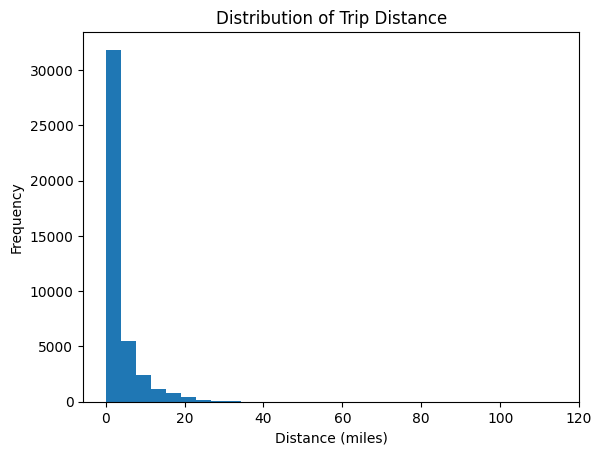

In [72]:
# Trip Distance Distribution

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['trip_distance'], bins=30)
plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.show()

# Most values on left
# Few large values
# Right-skewed

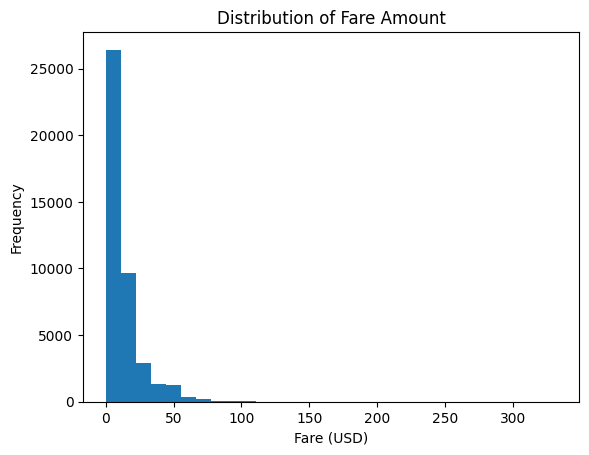

In [73]:
# Fare Amount Distribution

plt.figure()
plt.hist(df['fare_amount'], bins=30)
plt.title("Distribution of Fare Amount")
plt.xlabel("Fare (USD)")
plt.ylabel("Frequency")
plt.show()

# Similar to distance
# Right-skewed
# indicating that most trips are short and low-cost,
# while a few trips have high values..

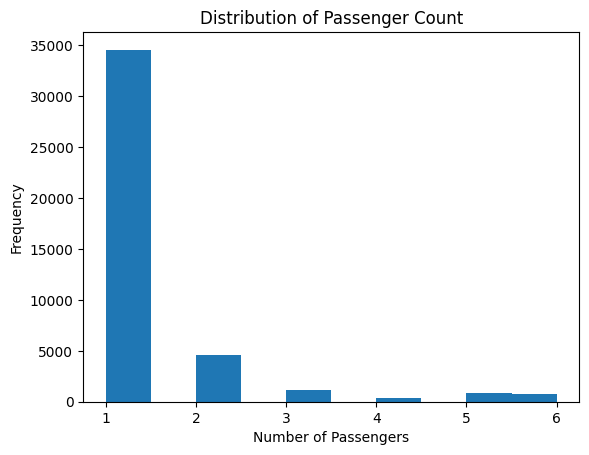

In [74]:
# Passenger Count Distribution

plt.figure()
plt.hist(df['passenger_count'], bins=10)
plt.title("Distribution of Passenger Count")
plt.xlabel("Number of Passengers")
plt.ylabel("Frequency")
plt.show()

# Here we can observe that Most trips: 1–2 passengers

Step 3: Time-Based Analysis (Seaborn)

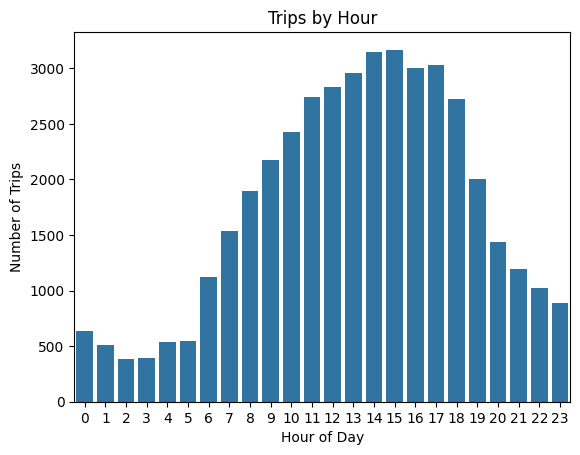

In [93]:
# Trips by Hour

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x='pickup_hour', data=df)
plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.show()

# we can observe peak hours of a day likely to have more trips.Also we can see that 15th Hour(Afternoon 3 pm) is identified as peak hour indicating higher demand during afternoon hours.This indicates that most trips are related to work and daily commuting.

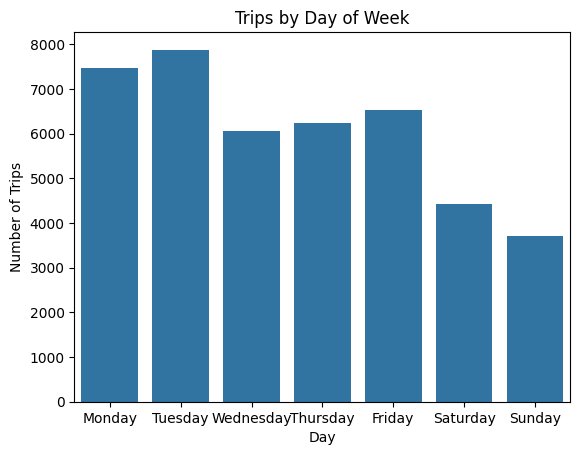

In [120]:
# Trips by Day

plt.figure()
sns.countplot(x='day_of_week', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.show()

# we can observe the demand of the trips that a particular day has..
# we can see that weekdays has the highest demand than the weekends, especially tuesday has the highest demand, whereas weekends-saturday and sunday has the least demand indicating most trips are related to work and daily commuting, and people's preference to stay at home at weekends..

In [95]:
# Identifying peak Hour

int(df['pickup_hour'].value_counts().idxmax())

# we can see that 15th Hour(Afternoon 3 pm) is identified as peak hour indicating higher demand during afternoon hours..

15

Step 4: Distance vs Fare

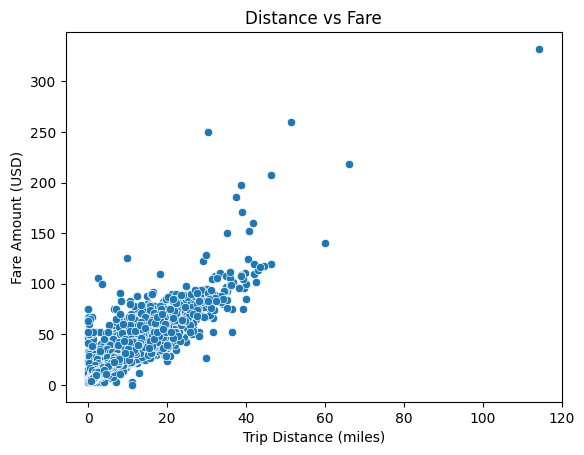

In [96]:
# Analyzing relationship (Distance vs Fare)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Distance vs Fare")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")
plt.show()

# As we can observe here points forming an incresing pattern... That means As the distance increases fare also increases..
# This indicates that the pricing is generally consistent with distance, although some variation exists due to additional factors.

Step 5: Tip Analysis

In [97]:
# Analyze relationship:

# Tip vs Fare
# Tip vs Distance

# To understand customer tipping behavior

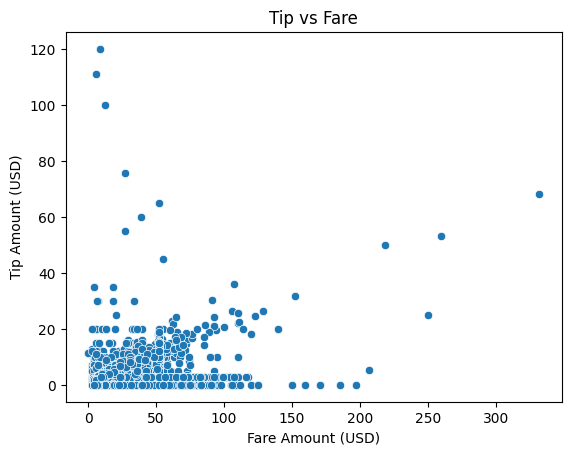

In [98]:
# Tip vs Fare

plt.figure()
sns.scatterplot(x='fare_amount', y='tip_amount', data=df)
plt.title("Tip vs Fare")
plt.xlabel("Fare Amount (USD)")
plt.ylabel("Tip Amount (USD)")
plt.show()

# The tip vs fare analysis shows a weak positive relationship. While higher fares sometimes result in higher tips, the pattern is not consistent. Many trips have zero or low tips, indicating that tipping behavior varies significantly and is influenced more by customer preference than fare alone.

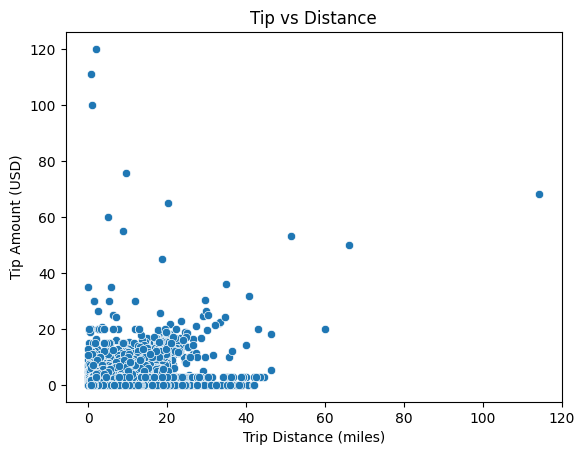

In [99]:
# Tip vs Distance

plt.figure()
sns.scatterplot(x='trip_distance', y='tip_amount', data=df)
plt.title("Tip vs Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount (USD)")
plt.show()

# The tip vs distance analysis shows no strong relationship, indicating that customers do not base their tips on how far they travel. Most tips remain low regardless of distance, suggesting that tipping behavior is largely influenced by individual customer preferences rather than trip length.

# While fare shows a slight influence on tips, distance does not, indicating that tipping behavior is not directly tied to trip length.

Step 6: Duration Analysis

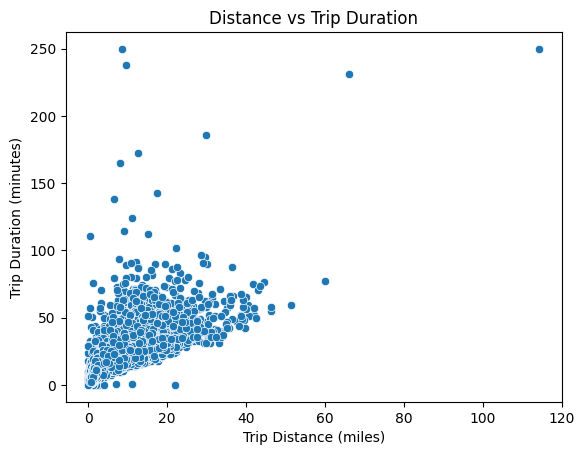

In [100]:
# Analyze relationship: trip_duration vs trip_distance

# To understand:Traffic conditions and Travel efficiency

plt.figure()
sns.scatterplot(x='trip_distance', y='trip_duration', data=df)
plt.title("Distance vs Trip Duration")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Trip Duration (minutes)")
plt.show()

# The analysis shows that trip duration increases with distance, but there is significant variation for similar distances. This indicates that traffic conditions play a major role in determining travel time, especially for shorter trips within the city.

# Travel time is influenced not only by distance but also by traffic congestion and route conditions.

Step 7: Passenger Analysis

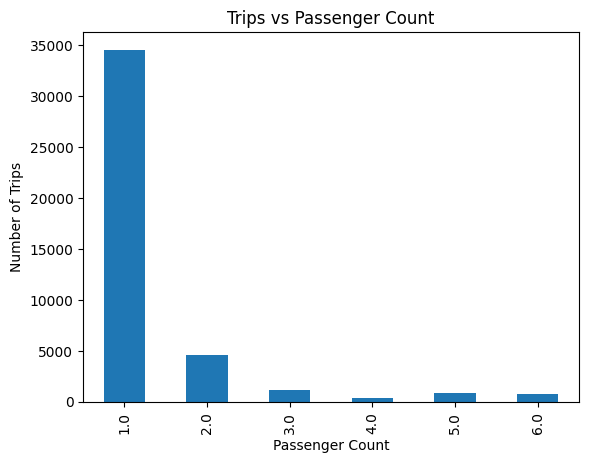

In [101]:
# Trips vs passenger_count

plt.figure()
df['passenger_count'].value_counts().sort_index().plot(kind='bar')
plt.title("Trips vs Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.show()

# The majority of trips are made by a single passenger, followed by trips with two passengers.
# Trips with higher passenger counts are significantly lower, indicating that most taxi usage is for individual or small group travel.

Step 8: Location Analysis

In [102]:
# PULocation(Pickup Location) vs DOLocation(Drop location)
# Finding most common routes

routes = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='trip_count')
routes = routes.sort_values(by='trip_count', ascending=False)

routes.head(10)

# # Here we can observe the most frequently traveled routes based on pickup and drop locations.
# A few routes have significantly higher trip counts, indicating popular travel paths within the city.
# This shows that taxi demand is concentrated in specific areas.

,PULocationID,DOLocationID,trip_count
6772,237,236,216
6669,236,236,192
7683,264,264,187
6670,236,237,184
1698,75,74,151
7542,263,75,148
6608,236,75,147
6965,239,238,138
1699,75,75,136
6773,237,237,130


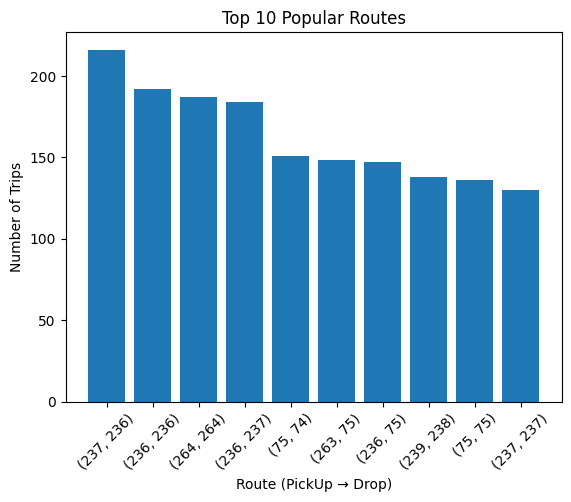

In [103]:
# Visualizing common routes

top_routes = routes.head(10)

plt.figure()
plt.bar(range(len(top_routes)), top_routes['trip_count'])
plt.xticks(range(len(top_routes)),
           list(zip(top_routes['PULocationID'], top_routes['DOLocationID'])),
           rotation=45)
plt.title("Top 10 Popular Routes")
plt.xlabel("Route (PickUp → Drop)")
plt.ylabel("Number of Trips")
plt.show()

Step 9: Correlation Analysis

In [104]:
# Analyze relationships between: fare_amount, trip_distance, trip_duration and tip_amount
# Using a heatmap

# Select required columns

corr_data = df[['fare_amount', 'trip_distance', 'trip_duration', 'tip_amount']]

In [105]:
# Compute correlation

corr_matrix = corr_data.corr()
corr_matrix

,fare_amount,trip_distance,trip_duration,tip_amount
fare_amount,1.000000,0.942779,0.820865,0.284655
trip_distance,0.942779,1.000000,0.804131,0.292327
trip_duration,0.820865,0.804131,1.000000,0.284845
tip_amount,0.284655,0.292327,0.284845,1.000000


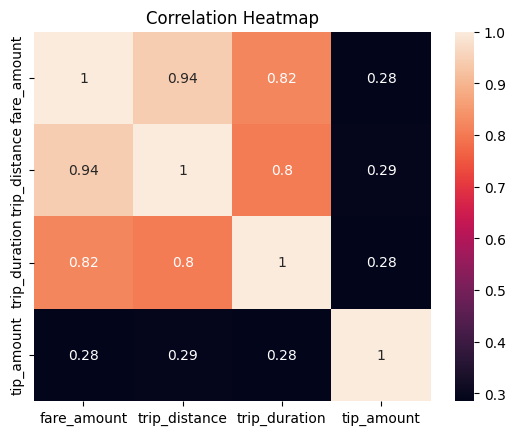

In [107]:
# Plot heatmap (Seaborn)

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# The correlation analysis shows strong relationships between distance, fare, and duration, indicating that these variables are closely related. However, tip amount shows weaker correlation, suggesting that tipping behavior is less dependent on trip characteristics.

SECTION 3: Insight Questions

Basic Insights

In [129]:
# 1.What is the average trip distance?

df['trip_distance'].mean()

# The avg trip distance is 3.49 miles..

np.float64(3.4948612489954143)

In [131]:
# 2. What is the average fare amount?

df['fare_amount'].mean()

# The avg fare amount is 13.59 USD

np.float64(13.59709875667754)

Trip Behavior

In [133]:
# 3. What is the most common passenger count?

df['passenger_count'].mode()[0]

# The most common passenger count is 1, indicating that most trips are taken by a single passenger.

np.float64(1.0)

In [137]:
# 4. What is the most frequent trip distance range?

df['trip_distance'].mode()[0]

# Most trips fall within a short distance range, typically around 1 mile, indicating that taxi usage is mainly for short-distance travel.

np.float64(1.0)

Time Insights

In [139]:
# 5. At what hour are most trips taken?
df['pickup_hour'].value_counts().idxmax()

# Most trips are taken around 15:00 (3 PM), indicating peak afternoon demand..

np.int32(15)

In [140]:
# 6. Which day has highest demand?
df['day_of_week'].value_counts().idxmax()

# Tuesday has the highest demand..

'Tuesday'

Pricing Insights

In [141]:
# 7. Does fare increase with distance?
print(df['fare_amount'].corr(df['trip_distance']))

# Yes, fare generally increases with distance, showing a positive relationship between trip distance and fare amount.

0.9427785515863464


<Axes: ylabel='total_amount'>

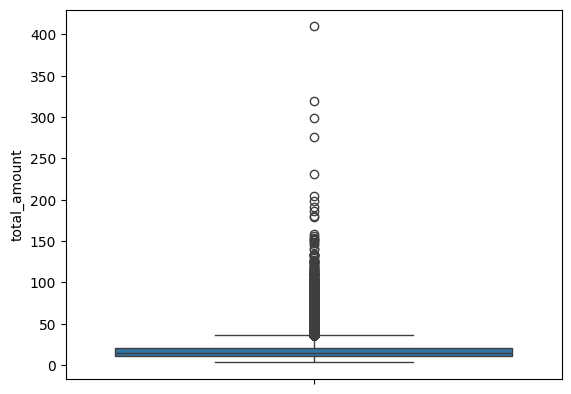

In [143]:
# 8. Are there pricing anomalies?

sns.boxplot(df['total_amount'])

#The box plot shows high price outliers which says some anomalies exist where trips with similar distances have significantly different fares.

Tip Insights

In [115]:
# 9. Do longer trips give higher tips?
print(df['trip_distance'].corr(df['tip_amount']))

# No we cannot say longer trips give higher tips as they are weakly related to each other..

In [146]:
# 10. Which trips receive no tips?

no_tip=df[df['tip_amount']==0]
no_tip['payment_type'].value_counts()

# Many trips across all distances receive no tips, indicating that tipping behavior depends on customer preference rather than trip characteristics.

,count
payment_type,
2,13165
1,3153
3,221
4,79
5,3


Operational Insights

In [147]:
# 11. Identify peak hours

int(df['pickup_hour'].value_counts().idxmax())

# we can see that 15th Hour(Afternoon 3 pm) is identified as peak hour indicating higher demand during afternoon hours..

15

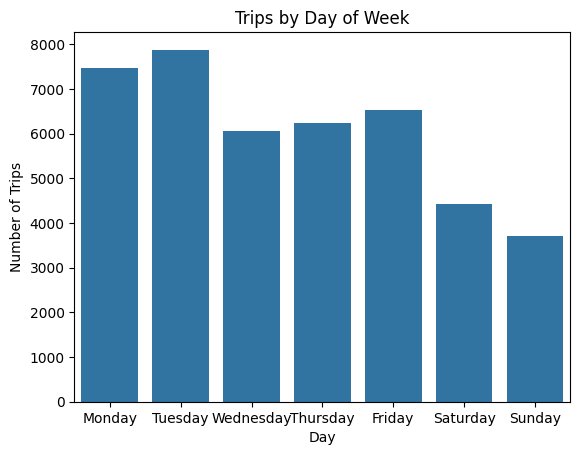

In [148]:
# 12. Compare weekday vs weekend demand
plt.figure()
sns.countplot(x='day_of_week', data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.show()
# Demand is significantly higher on weekdays compared to weekends, with weekends showing lower trip counts, especially on Sunday.

Outlier Insights

In [150]:
# 13. Identify extremely high fares
#using IQR

Q1=df['fare_amount'].quantile(0.25)
Q3=df['fare_amount'].quantile(0.75)

upper_limit=Q3+1.5*(Q3-Q1)

higher_fares = df[df['fare_amount']>upper_limit]
print(higher_fares.shape)
print("Upper_limit =",upper_limit)

higher_fares[["fare_amount"]].head()

# A few trips have extremely high fares, which appear as outliers in the data and may represent long-distance trips or anomalies.

(4495, 26)
Upper_limit = 27.75


,fare_amount
519501,28.81
523027,27.89
521479,42.70
304163,52.00
214150,45.00


In [153]:
# 14. Identify unrealistic trips

(df["trip_distance"]>300).sum()
# Some trips had unrealistic values such as zero or negative durations, which were removed during data cleaning to ensure accuracy.

np.int64(0)

In [157]:
(df['trip_speed']>120).sum()
#25 trips have speed greater than 120 which are unrealistic trips

np.int64(25)

Advanced Insights

In [155]:
# 15. Identify inefficient trips (long duration, low distance)

df[(df['trip_distance'] < 2) & (df['trip_duration'] > 60)]

# Some trips have long durations despite short distances, indicating traffic congestion or inefficiency.

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,pickup_hour,pickup_day,day_of_week,month,trip_duration,fare_per_km,tip_percentage,trip_speed
46054,1.0,2020-06-04 13:34:44,2020-06-04 14:50:31,1.0,1.20,1.0,N,140,140,2,...,43.30,2.5,13,4,Thursday,6,75.783333,33.333333,0.0,0.950077
321152,2.0,2020-06-22 15:11:46,2020-06-22 17:02:15,1.0,0.56,5.0,N,74,75,2,...,17.37,0.0,15,22,Monday,6,110.483333,29.589286,0.0,0.304118


In [158]:
# 16. Identify abnormal pricing patterns

#high or low fare_per_km

df[(df['fare_per_km']>10) | (df['fare_per_km']<2)].shape

(1346, 26)

In [159]:
# low distance but high fare

df[(df["trip_distance"] < 10) & (df["fare_amount"] > 100)][["trip_distance","fare_amount"]]

,trip_distance,fare_amount
149799,2.40,106.0
453507,9.77,125.0


In [160]:
# high distance but low fare

df[(df["trip_distance"] > 80) & (df["fare_amount"] < 80)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,pickup_hour,pickup_day,day_of_week,month,trip_duration,fare_per_km,tip_percentage,trip_speed


Visualization Tasks

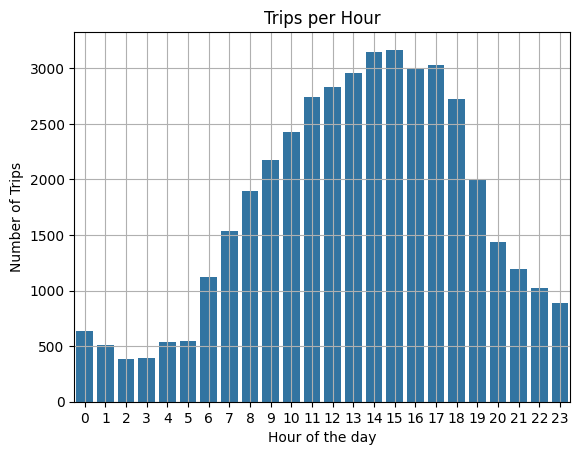

In [162]:
# 17. Trips per hour plot

sns.countplot(x="pickup_hour",data=df)
plt.grid()
plt.title("Trips per Hour")
plt.xlabel("Hour of the day")
plt.ylabel("Number of Trips")
plt.show()

#we can observe peak hours as 14,15,17

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

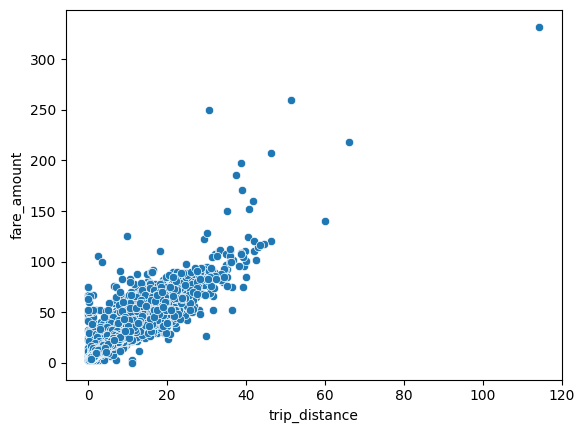

In [163]:
# 18. Fare vs distance scatter

sns.scatterplot(x="trip_distance",y="fare_amount",data=df)

#Both are positively and strongly related

<Axes: ylabel='fare_amount'>

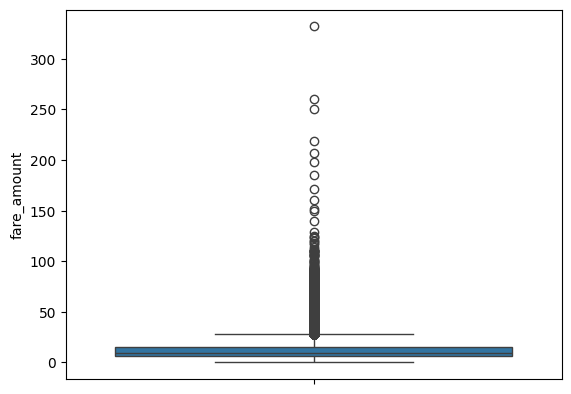

In [164]:
# 19. Boxplot for outliers

sns.boxplot(df["fare_amount"])

#we can see many outliers

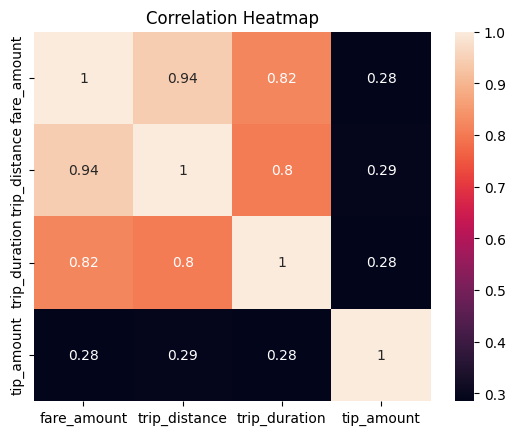

In [165]:
# 20. Correlation heatmap

plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# The correlation analysis shows strong relationships between distance, fare, and duration, indicating that these variables are closely related. However, tip amount shows weaker correlation, suggesting that tipping behavior is less dependent on trip characteristics.

Cleaned Dataset

In [167]:
df.to_csv("cleaned_taxi_data.csv", index=False)

In [168]:
from google.colab import files
files.download("cleaned_taxi_data.csv")

# I saved the cleaned dataset using pandas to_csv() function, ensuring it contains only processed and validated data.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [170]:
# Checking to ensure no missing values

df.shape

(42306, 26)

In [171]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


Final Conclusion(Insight Summary):

. The analysis of the taxi trip dataset provides valuable insights into travel patterns,pricing behavior, and customer preferences.

. Most trips are short in distance and involve a single passenger, indicating that taxi's are primarily used for individual and short-distance travel.

. Time-based analysis shows that demand is higher during weekdays, with peak activity observed in the afternoon hours, reflecting work-related commuting patterns.

. A strong positive relationship exists between trip distance, fare amount, and trip duration, confirming that pricing is generally consistent with distance traveled.

. However, tipping behavior is highly variable and does not strongly depend on trip distance, suggesting that it is influenced more by individual customer preferences.

. The dataset also revealed the presence of outliers and some inefficient trips,highlighting the impact of traffic conditions and occasional data irregularities.

. Overall, the dataset is clean, consistent, and provides meaningful insights into taxi operations, customer behavior, and urban travel dynamics.